# Analysis for the Friedman benchmark

TODO Update with new SRB samples

The data sets are:

1. `f1a`: $f_1$ on 100 data points, no distractors
2. `f1b`: $f_1$ on 1000 data points, no distractors
3. `f1c`: $f_1$ on 100 data points, 5 columns of distractors
4. `f1d`: $f_1$ on 1000 data points, 5 columns of distractors

## Prelude

In [1]:
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sympy

import AnalysisUtils as au

In [3]:
sns.set_theme("notebook", style="darkgrid")

## Loading data

In [4]:
f1expr = sympy.sympify("10*sin(π*x1*x2) + 20*(x3 - 1/2)^2 + 10*x4 + 5*x5")
f1expr

10*x4 + 5*x5 + 20*(x3 - 1/2)**2 + 10*sin(x1*x2*π)

In [5]:
sympy.expand(f1expr)

20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(x1*x2*π) + 5

These are the results of Jessamine symbolic regression.

In [6]:
full_report = pd.read_csv("Generated/full-report.csv")

In [7]:
full_report["sympy"] = full_report.expr_original_syms.apply(lambda e: au.parse_if_needed(e))
full_report["complexity"] = full_report.sympy.apply(lambda e: au.complexity(e))
full_report["sympy_defuzz"] = full_report.sympy.apply(lambda e: au.replace_near_integer(e.evalf()))
full_report["complexity_defuzz"] = full_report.sympy_defuzz.apply(lambda e: au.complexity(e))

In [8]:
full_report.run_set.unique()

array(['CHT-2026-06-25-1700', 'CHT-2026-06-25-1700-subset',
       'SRB-2026-06-25-1715-arr8', 'SRB-2026-06-25-1715-subset',
       'SRB-2026-07-13-1130', 'SRB-2026-07-13-1130-subset'], dtype=object)

Make rows indexable by run set, data set, and sample number.

In [9]:
fr1 = full_report.sort_values(["run_set", "data_set", "mse"])
fr2 = fr1.set_index(["run_set", "data_set", "sample_num"])
fr2.sort_index(inplace=True)

In [10]:
all_min_mse_ixs = fr2.groupby(level=["run_set", "data_set"]).mse.idxmin()
fr2.loc[all_min_mse_ixs]

rating           mse  \
run_set                    data_set sample_num                               
CHT-2026-06-25-1700        f1a      7           1.321361e-09  9.737038e-11   
                           f1b      23          4.182807e-10  2.339731e-11   
                           f1c      22          2.066700e-09  4.848005e-10   
                           f1d      7           1.241467e-09  6.070972e-10   
CHT-2026-06-25-1700-subset f1b      23          4.182807e-10  2.339731e-11   
                           f1d      7           1.241467e-09  6.070972e-10   
SRB-2026-06-25-1715-arr8   f1a      31          1.163767e-09  3.235317e-11   
                           f1b      24          7.495778e-09  3.063588e-10   
                           f1c      18          3.253055e-05  3.252853e-05   
                           f1d      12          2.749208e-01  2.749208e-01   
SRB-2026-06-25-1715-subset f1b      24          7.495778e-09  3.063588e-10   
                           f1d      12          2.749208e-01  2.749208e-01   
SRB-2026-07-13-1130        f1a      9           4.884131e-10  1.813714e-10   
                           f1b      22          3.644612e-10  1.422362e-10   
                           f1c      3           1.065773e-09  4.504061e-10   
                           f1d      19          2.491303e-04  2.491255e-04   
SRB-2026-07-13-1130-subset f1b      22          3.644612e-10  1.422362e-10   
                           f1d      23          1.069836e-08  1.733623e-09   

                                                                               expr_original_syms  \
run_set                    data_set sample_num                                                      
CHT-2026-06-25-1700        f1a      7           -5.15001869345741e-5*x1 - 20.00000787358523*x3...   
                           f1b      23          -4.801974450056612e-6*x2**2 + 2.39902748981315...   
                           f1c      22          -7.025813765112854e-6*x2 + 19.99999347698159*x...   
                           f1d      7           -2.096867827314014e-6*x10 + 10.0000166626068*x...   
CHT-2026-06-25-1700-subset f1b      23          -4.801974450056612e-6*x2**2 + 2.39902748981315...   
                           f1d      7           -2.096867827314014e-6*x10 + 10.0000166626068*x...   
SRB-2026-06-25-1715-arr8   f1a      31          4.8118085730075588e-6*x2 + 19.999971052865682*...   
                           f1b      24          -6.514036366711647e-5*x2 + 19.999963796810725*...   
                           f1c      18          0.005411818139977574*x10**2*x2**4 - 0.00187084...   
                           f1d      12          -32.878677010362644*x1**3*x2**3 + 27.963427930...   
SRB-2026-06-25-1715-subset f1b      24          -6.514036366711647e-5*x2 + 19.999963796810725*...   
                           f1d      12          -32.878677010362644*x1**3*x2**3 + 27.963427930...   
SRB-2026-07-13-1130        f1a      9           6.383904224859005e-7*x1*x3 + 8.72004215104982e...   
                           f1b      22          9.999997997773806*x4 + 4.999910979641707*x5 + ...   
                           f1c      3           10.00000883079833*x4 + 5.000016851780695*x5 - ...   
                           f1d      19          -0.0019474446378310029*x10 + 19.99533042639424...   
SRB-2026-07-13-1130-subset f1b      22          9.999997997773806*x4 + 4.999910979641707*x5 + ...   
                           f1d      23          20.000004071776596*x3**2 - 20.000005369056077*...   

                                                                                             expr  \
run_set                    data_set sample_num                                                      
CHT-2026-06-25-1700        f1a      7           -5.15001869345741e-5*x1 - 20.00000787358523*x3...   
                           f1b      23          -4.801974450056612e-6*x2**2 + 2.39902748981315...   
                           f1c      22          -7.025813765112854e-

In [11]:
srb1 = fr2.loc["SRB-2026-06-25-1715-arr8"]
srb2 = fr2.loc["SRB-2026-07-13-1130"]
srb2s = fr2.loc["SRB-2026-07-13-1130-subset"]
cht1 = fr2.loc["CHT-2026-06-25-1700"]
cht1s = fr2.loc["CHT-2026-06-25-1700-subset"]

In [12]:
srb1.groupby(level=["data_set"]).size()

data_set
f1a    32
f1b    32
f1c    32
f1d    32
dtype: int64

In [13]:
srb2.groupby(level=["data_set"]).size()

data_set
f1a    32
f1b    32
f1c    32
f1d    32
dtype: int64

In [14]:
srb2s.groupby(level=["data_set"]).size()

data_set
f1b    32
f1d    32
dtype: int64

In [15]:
cht1.groupby(level=["data_set"]).size()

data_set
f1a    32
f1b    32
f1c    32
f1d    32
dtype: int64

In [16]:
cht1s.groupby(level=["data_set"]).size()

data_set
f1b    32
f1d    32
dtype: int64

These are the best ones overall

In [17]:
srb1_min_mse_ixs = srb1.groupby(level=["data_set"]).mse.idxmin()
srb2_min_mse_ixs = srb2.groupby(level=["data_set"]).mse.idxmin()
srb2s_min_mse_ixs = srb2s.groupby(level=["data_set"]).mse.idxmin()
cht1_min_mse_ixs = cht1.groupby(level=["data_set"]).mse.idxmin()
cht1s_min_mse_ixs = cht1s.groupby(level=["data_set"]).mse.idxmin()

In [18]:
srb1.loc[srb1_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1a,31,3.235317e-11,31,19.9999710528657*x3**2 - 19.9999889115256*x3 +...
f1b,24,3.063588e-10,43,-6.51403636671165e-5*x2 + 19.9999637968107*x3*...
f1c,18,3.252853e-05,45,0.00541181813997757*x10**2*x2**4 - 0.001870843...
f1d,12,2.749208e-01,48,-32.8786770103626*x1**3*x2**3 + 27.96342793081...


In [19]:
srb2.loc[srb2_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1a,9,1.813714e-10,29,4.49509084478334e-5*x2 - 4.55892988703193e-5*x...
f1b,22,1.422362e-10,53,10*x4 + 4.99991097964171*x5 + 5*(2*x3 - 1)**2 ...
f1c,3,4.504061e-10,21,10*x4 + 5.0000168517807*x5 + 20.0000537003694*...
f1d,19,2.491255e-04,46,-0.001947444637831*x10 + 19.9953304263942*x3**...


In [20]:
srb2s.loc[srb2s_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1b,22,1.422362e-10,53,10*x4 + 4.99991097964171*x5 + 5*(2*x3 - 1)**2 ...
f1d,23,1.733623e-09,23,20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...


In [21]:
cht1.loc[cht1_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1a,7,9.737038e-11,26,-5.15001869345741e-5*x1 + 20*x3**2 - 20.000034...
f1b,23,2.339731e-11,28,-3.28697105760334e-5*x4*tan(x3) + 10.000019174...
f1c,22,4.848005e-10,23,20*x3**2 - 20*x3 + 10.0000145558494*x4 + 5.000...
f1d,7,6.070972e-10,28,10.0000166626068*x4 + 5*x5 + 20*(0.50000214578...


In [22]:
cht1s.loc[cht1s_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1b,23,2.339731e-11,28,-3.28697105760334e-5*x4*tan(x3) + 10.000019174...
f1d,7,6.070972e-10,28,10.0000166626068*x4 + 5*x5 + 20*(0.50000214578...


In [23]:
srb1.groupby(by="data_set").agg(
    complexity_mean=("complexity", "mean"),
    complexity_defuzz_mean=("complexity_defuzz", "mean"),
    complexity_std=("complexity", "std"),
    complexity_defuzz_std=("complexity_defuzz", "std"),
    complexity_min=("complexity", "min"),
    complexity_max=("complexity", "max"),
    complexity_defuzz_min=("complexity_defuzz", "min"),
    complexity_defuzz_max=("complexity_defuzz", "max"),
).sort_values("complexity_min", ascending=True)

,complexity_mean,complexity_defuzz_mean,complexity_std,complexity_defuzz_std,complexity_min,complexity_max,complexity_defuzz_min,complexity_defuzz_max
data_set,,,,,,,,
f1a,42.65625,38.3125,13.927484,13.513285,23,74,22,74
f1b,52.65625,50.1250,15.457766,15.173725,25,92,25,92
f1d,67.31250,63.3750,29.840909,28.511175,32,153,32,153
f1c,74.21875,67.1250,34.888518,29.777400,36,176,25,166


In [24]:
srb2.groupby(by="data_set").agg(
    complexity_mean=("complexity", "mean"),
    complexity_defuzz_mean=("complexity_defuzz", "mean"),
    complexity_std=("complexity", "std"),
    complexity_defuzz_std=("complexity_defuzz", "std"),
    complexity_min=("complexity", "min"),
    complexity_max=("complexity", "max"),
    complexity_defuzz_min=("complexity_defuzz", "min"),
    complexity_defuzz_max=("complexity_defuzz", "max"),
).sort_values("complexity_min", ascending=True)

,complexity_mean,complexity_defuzz_mean,complexity_std,complexity_defuzz_std,complexity_min,complexity_max,complexity_defuzz_min,complexity_defuzz_max
data_set,,,,,,,,
f1a,59.0625,45.56250,29.172388,18.268495,24,155,23,94
f1b,78.5000,72.56250,35.986557,34.589703,30,170,23,149
f1c,63.2500,59.25000,27.382594,27.809258,30,119,21,119
f1d,72.6875,61.03125,59.928687,21.752989,36,378,35,125


In [25]:
cht1.groupby(by="data_set").agg(
    complexity_mean=("complexity", "mean"),
    complexity_defuzz_mean=("complexity_defuzz", "mean"),
    complexity_std=("complexity", "std"),
    complexity_defuzz_std=("complexity_defuzz", "std"),
    complexity_min=("complexity", "min"),
    complexity_max=("complexity", "max"),
    complexity_defuzz_min=("complexity_defuzz", "min"),
    complexity_defuzz_max=("complexity_defuzz", "max"),
).sort_values("complexity_min", ascending=True)

,complexity_mean,complexity_defuzz_mean,complexity_std,complexity_defuzz_std,complexity_min,complexity_max,complexity_defuzz_min,complexity_defuzz_max
data_set,,,,,,,,
f1a,41.0000,37.43750,13.018597,14.296261,23,75,23,75
f1b,55.4375,51.75000,21.110978,21.388873,27,102,24,102
f1c,53.6875,50.62500,15.738667,16.159986,31,93,22,93
f1d,74.7500,72.46875,67.795232,67.655190,36,432,28,432


In [26]:
au.count_by_threshold(srb1, threshold=1.0e-7)

data_set
f1a    18
f1b     6
f1c     0
f1d     0
Name: mse, dtype: int64

### A bit about `srb1`

The best for `f1a` and `f1b` are exactly correct up to fuzz.
For `f1c`, it found several correct terms, but with one cruft term involving distractors $x_6$ and $x_7$, and a wrong term involving $x_3$ that seems to be an approximation for $20(x_3 - 1/2)^2$ using $1 - \cos (x_3 - 1/2) \approx (1/2)(x_3 - 1/2)^2$.
For `f1d`, it's just lost.

In [27]:
(srb1.loc[srb1_min_mse_ixs]
 .sympy_defuzz
 .apply(lambda e: au.replace_near_integer(e, tolerance=1.0e-2)))

data_set  sample_num
f1a       31            20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
f1b       24            20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
f1c       18            10*x4 + 5*x5 + 10*sin(3.1413505378038034*x1*x2...
f1d       12            -32.8786770103626*x1**3*x2**3 + 27.96342793081...
Name: sympy_defuzz, dtype: object

In [28]:
(srb1.loc[srb1_min_mse_ixs]
 .sympy_defuzz
 .apply(lambda e: au.replace_near_integer(e, tolerance=1.0e-2)))

data_set  sample_num
f1a       31            20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
f1b       24            20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
f1c       18            10*x4 + 5*x5 + 10*sin(3.1413505378038034*x1*x2...
f1d       12            -32.8786770103626*x1**3*x2**3 + 27.96342793081...
Name: sympy_defuzz, dtype: object

Looks like `srb2` is better.

Oddly, a lot of these have the correct terms, but they have a lot of extra cruft.
That means there's probably some numerical challenge with the process of solving for constants.

In [29]:
srb1.loc["f1a", ["mse", "complexity_defuzz", "sympy_defuzz"]]

,mse,complexity_defuzz,sympy_defuzz
sample_num,,,
1,4.206204e-05,28,-30.5631676191191*x4 + 4.99909763886888*x5 - 0...
2,1.249572e-09,22,9.99998454925853*x4 + 5.00001477974884*x5 + 20...
3,1.032178e-02,74,0.0340462596086298*x1 + 0.717080516628369*x3**...
4,3.202771e-05,38,0.006813777337771*x1**3 + 0.0060491236575944*x...
5,4.509047e-06,53,0.0126384932747639*x1 - 0.0101570866155793*x2 ...
6,4.535662e-07,37,-0.000680641880233163*x1 + 20.0016591339802*x3...
7,9.985719e-10,33,-5.6542552263429e-5*x1 + 10.0000204917352*x4 +...
8,9.357739e-05,37,-401.372718334513*x3 + 10.003454001943*x4 + 4....
9,1.616005e-09,34,-0.00027308428777603*x1**3 + 0.000123400324238...


With generous defuzzing, we get 21 correct samples.

In [30]:
srb1.loc["f1a"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -30.5631676191191*x4 + 5*x5 + 10*sin(3.1409517...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
3     19.2468925853138*x3**2 - 20.6753764983373*x3 +...
4     10*x4 + 5*x5 + 10*sin(3.1419837307157015*x1*x2...
5     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.142...
6     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     -401.372718334513*x3 + 10*x4 + 5*x5 + 3824.170...
9     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
10    20.1020184190166*x1**3*cos(x2)**3 + 2.08938764...
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
12    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
13    -0.0320333151496512*x2**2 + 25.8819238997677*x...
14    20*x3**2 - 9.56537848439849*x3 + 10*x4 + 5*x5 ...
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
16    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
18    20*x3**2 - 20*x3 + 10*x4 + 5*x5

In [31]:
srb1.loc["f1b"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     3*x1 - 3.57149528847672*x2 + 19.4764503392073*...
2     55.1530182897451*x3**3 - 15.1382706512854*x3 +...
3     -8.26068199609363*x1**2 + 16.5213639921873*x1*...
4     -0.0332075104236528*x1**8*x2 - 0.0204680296994...
5     -28.3969553172594*x1**2*x2 - 28.3969553172594*...
6     -0.538305047487001*x1 - 0.0223142897612089*x2*...
7     5.04203156637662*x3**3 + 12.3930946876671*x3**...
8     -21.0621068428252*x4 + 5*x5 + 10*sin(3.1415593...
9     -5.84110443586778*x1**3*x2**3 - 32.51077527916...
10    -0.0288547209496379*x1 - 0.0345068146658545*x2...
11    -3.05773073401995*x1**3 - 40.6252905436627*x1*...
12    10*x3 + 10*x4 + 5*x5 - 2.91267083472482*exp(x3...
13    -25.3786955503797*x1**6*x2**3 + 39.08498640957...
14    0.445660035335522*x2*cos(x4 + x5 + 0.482960283...
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
16    41.522595902175*x1*x2 - 0.134637272600702*x1 +...
17    2.65548804574316*x1 + 0.792028240963594*x2 - 4...
18    -0.731218103705247*x1 - 0.79667

Not much luck here:

In [32]:
srb1.loc["f1c"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -1.05502368955392*x1**3 + 1.05502368955392*x1*...
2     42.9059948989689*x1*x2 + 0.178366327282064*x1 ...
3     19.7684143416975*x1**4*x2**4 - 39.526482511311...
4     43.5849079511357*x3 + 0.0340191280814764*x5 + ...
5     15*x3 + 10*x4 + 5*x5 + 10*sin(3.13829375120942...
6     0.930957060412934*x1**2 + 1.86191412082587*x1*...
7     55.8921960800462*x3 + 9.96177988220731*x4 + 0....
8     0.0434214351181217*x1*x2**2 + 242.056113964321...
9     -0.378200043493597*x1**3*x2**3 - 44.6976652680...
10    -36.8010287424325*x1 + 22.0433375834794*x2 + 9...
11    0.759275520332252*x1**2 - 0.508629008598241*x1...
12    -8.16340974108103*x2**3 + 9*x2 - 0.47734162148...
13    -0.472351342403235*x1**2 - 0.472351342403235*x...
14    -1.74036650531653*x1 + 1.50208525262651*x2**2 ...
15    -0.0643678048027511*x1**9 - 0.053485913484803*...
16    -17.281323944997*x1**3 - 35.0640108211827*x1**...
17    10.9283712187088*x3**3 + 0.0418255447365167*x3...
18    10*x4 + 5*x5 + 10*sin(3.1413505

In [33]:
srb1.loc["f1d"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -20.8629770161564*x3 + 10.3864615907667*x4 + 5...
2     -0.0287579194994786*x1 + 0.300750106834458*x10...
3     -11.480892726242*x1**3 + 17.5446506412198*x1 -...
4     -0.125600621426448*x1**7*x2 - 0.09643119530053...
5     1.21583156873487*x1 - 1.16462895204349*x10 + 2...
6     -0.210879008034469*x1**6 - 1.26527404820681*x1...
7     -9.62586318397*x1 + 0.443833983964372*x1*exp(-...
8     18.4748863035355*x1**0.5 - 8.07937992798355*x1...
9     -0.437793332125239*x10 + 3.03224450186338*x2 +...
10    0.0216543564729514*x1**3 + 0.0649630694188541*...
11    -0.0387200732333259*x1 - 0.0387200732333259*x1...
12    -32.8786770103626*x1**3*x2**3 + 27.96342793081...
13    -0.0256183504353039*x1**14*x2 - 0.070468462985...
14    -17.8557011517761*x2 + 25.2829744654779*x3**3 ...
15    -1.55843755633971*x1 + 0.189170830502076*x10 +...
16    1.7608635005543*x1 + 0.100695248419514*x10**2 ...
17    -10.853041519468*x1**3 - 33.1296200529435*x1**...
18    5.97543489430178*x1 + 0.1701132

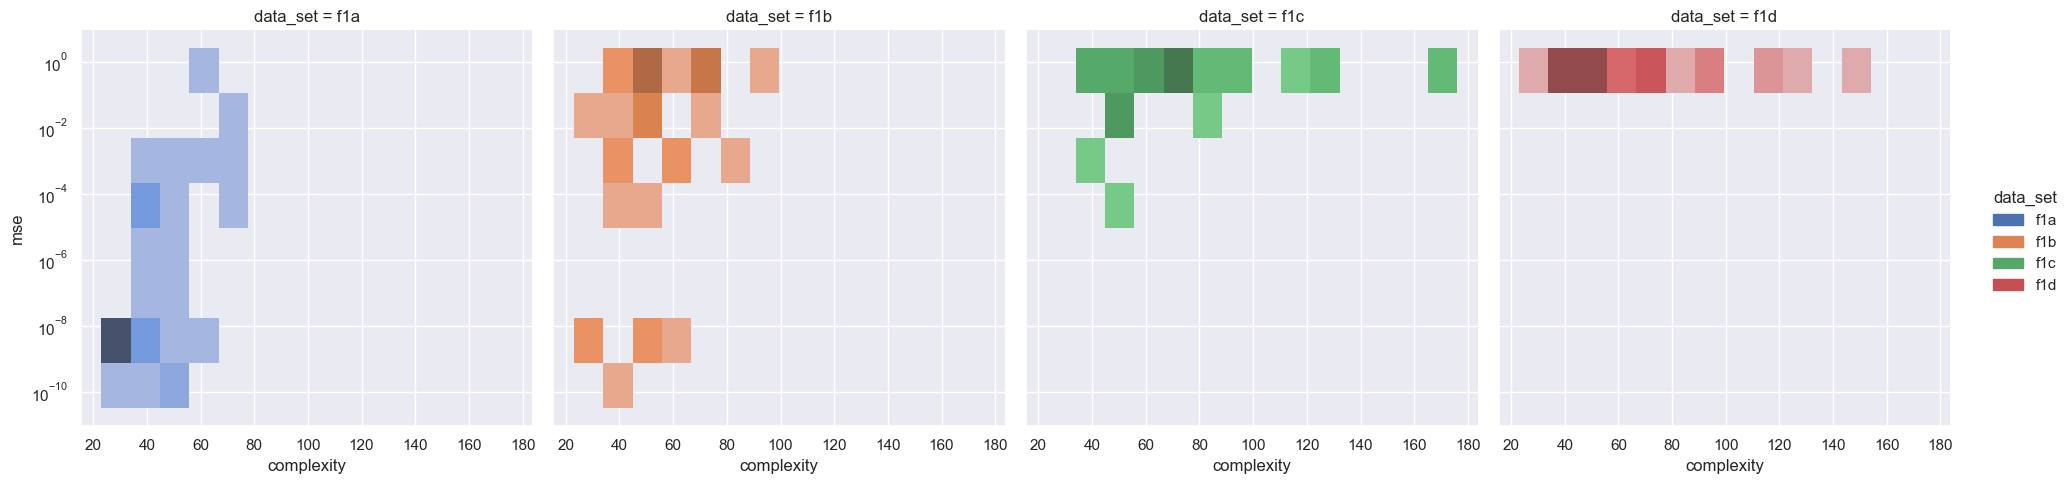

In [34]:
sns.displot(data=srb1,
            x="complexity",
            y="mse",
            col="data_set",
            hue="data_set",
            log_scale=[False,True],
            )

## Main SRB and CHT results

In [35]:
srb = srb2
srb_min_mse_ixs = srb2_min_mse_ixs
srbs = srb2s
srbs_min_mse_ixs = srb2s_min_mse_ixs
cht = cht1
cht_min_mse_ixs = cht1_min_mse_ixs
chts = cht1s
chts_min_mse_ixs = cht1s_min_mse_ixs

In [36]:
plot_params = {
    "complexity_lims": (0, 449),
    "complexity_col": "complexity_defuzz",
    "mse_lims": (1.0e-12, 0.99e2),
    "complexity_binwidth": 20,
    "mse_binwidth": 0.8,
    "spiffy_titles": ["F1a", "F1b", "F1c", "F1d"],
    "xlabel": "Complexity (defuzzed)",
    "ylabel": "MSE",
}

In [37]:
plot_params_bd = { **plot_params, "spiffy_titles": ["F1b", "F1d"] }

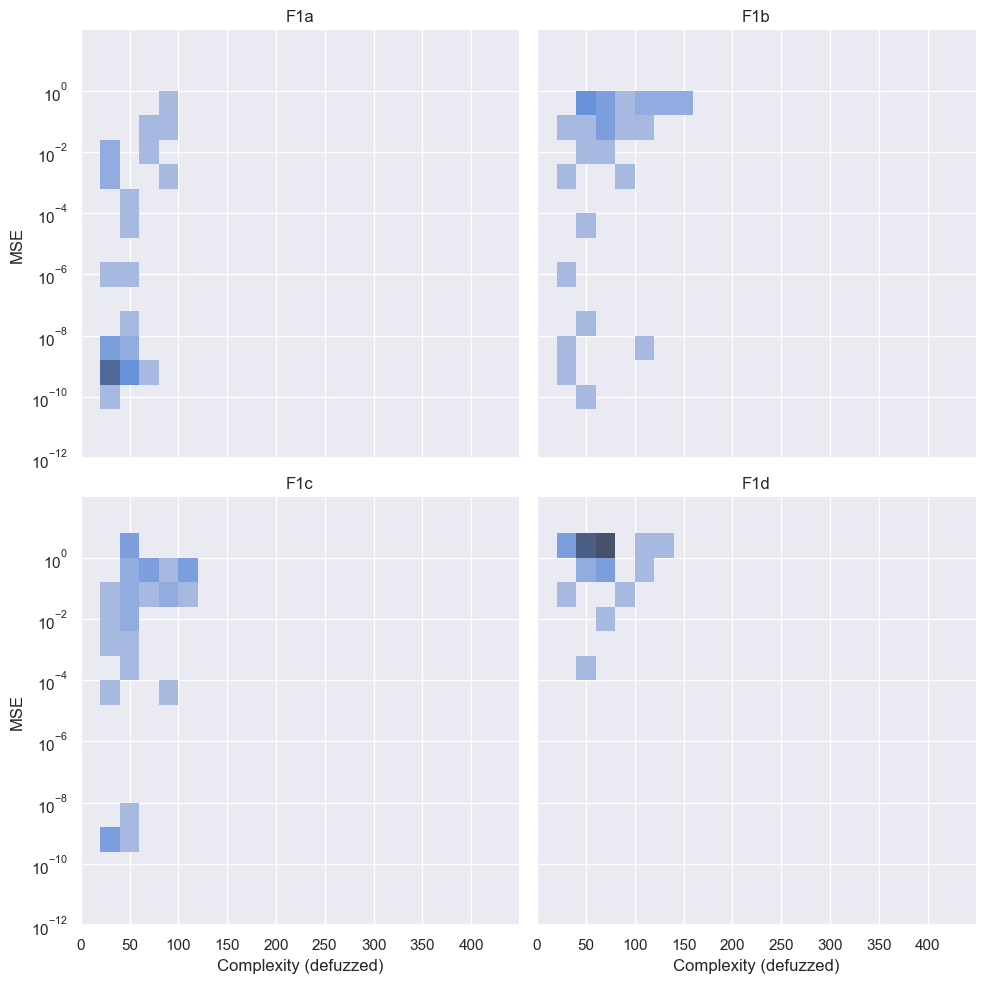

In [38]:
fig = au.complexity_mse_displot(srb, file_stem="SRB-complexity-mse-displot", **plot_params)

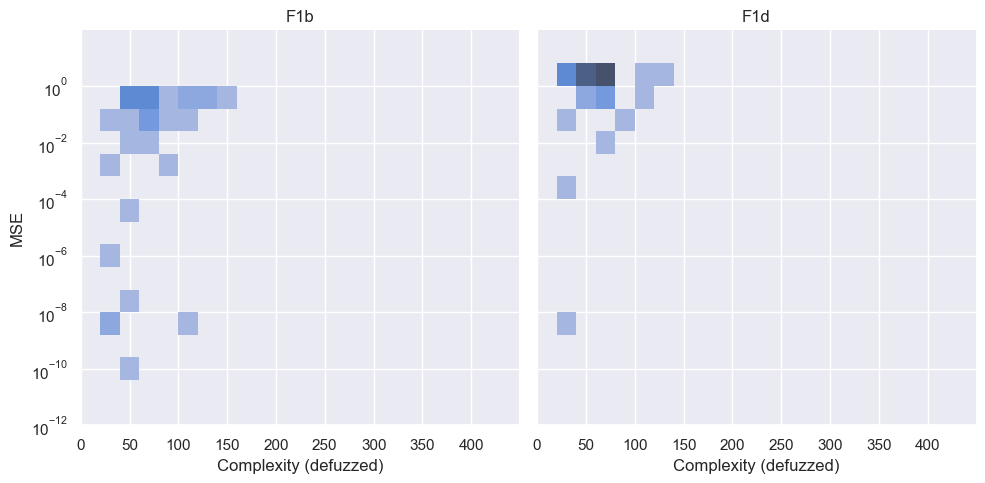

In [39]:
au.complexity_mse_displot(srbs, file_stem="SRBS-complexity-mse-displot", **plot_params_bd)

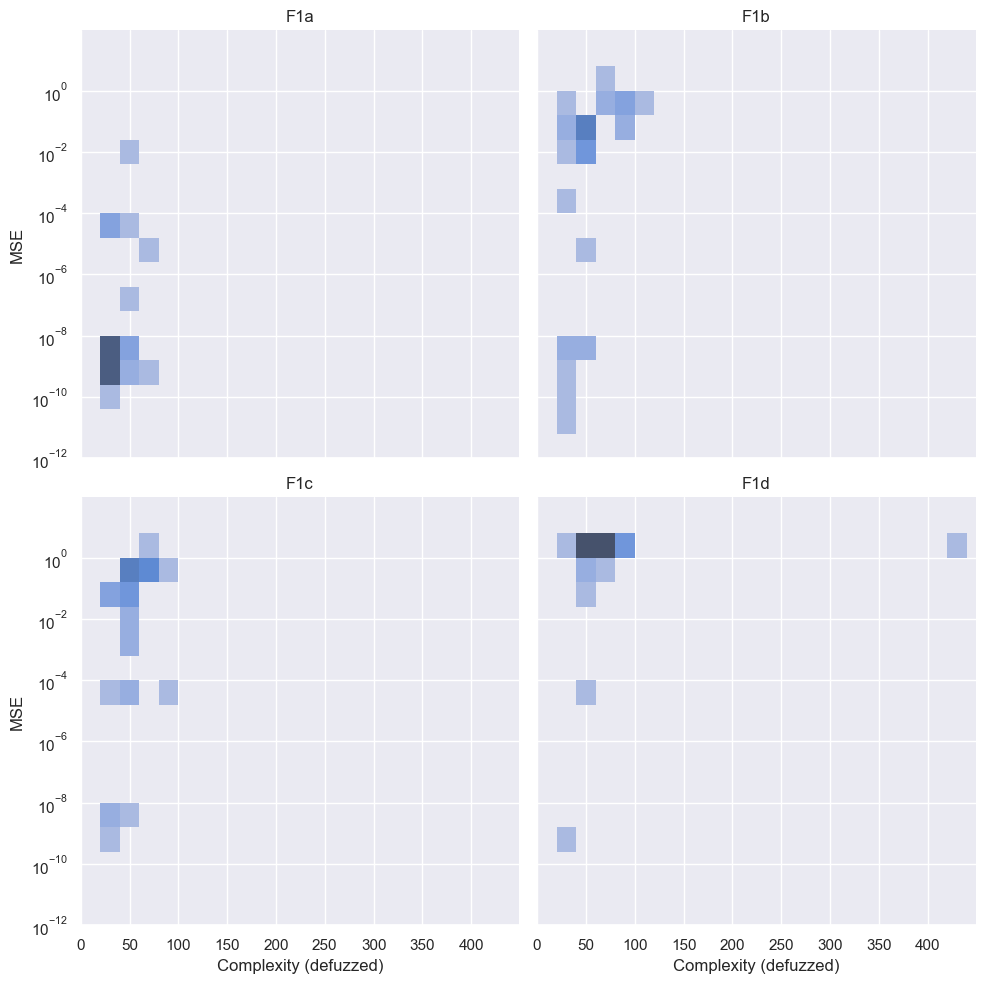

In [40]:
fig = au.complexity_mse_displot(cht, file_stem="CHT-complexity-mse-displot", **plot_params)

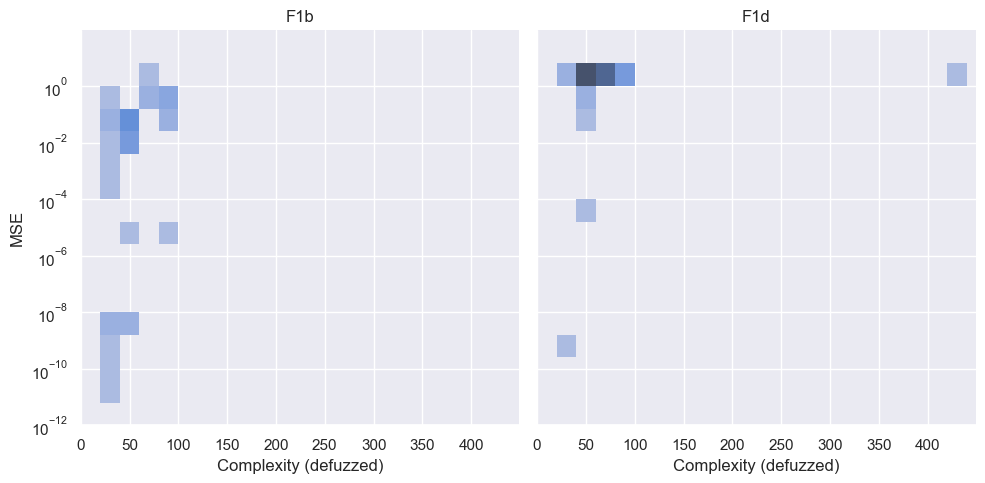

In [41]:
au.complexity_mse_displot(chts, file_stem="CHTS-complexity-mse-displot", **plot_params_bd)

In [42]:
au.count_by_threshold(srb, threshold=1.0e-7)

data_set
f1a    19
f1b     5
f1c     5
f1d     0
Name: mse, dtype: int64

In [43]:
au.count_by_threshold(srbs, threshold=1.0e-7)

data_set
f1b    5
f1d    1
Name: mse, dtype: int64

Looks like about 17 correct and a couple with cruft and some trig weirdness.

In [44]:
srb.loc["f1a"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
3     2.59515397918529*x1**2 - 1.54095944781899*x1 -...
4     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
5     1.83634334821559*x3**3 + 17.2986003127465*x3**...
6     -0.592591659710153*x1**3*x2**3 + 89.7408385196...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     20*x3**2 - 20*x3 + 10.433617883799*x4 + 5*x5 +...
9     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
10    -0.208961321213901*x1**4*x2**4 + 2.70898480235...
11    -14.1363594093721*x2**2*(2*x2 + x4 + 0.8414709...
12    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
14    66.8835377866472*x1*x2 + 10*x2 - 0.55675265511...
15    -33.7999715941764*x3 + 10*x4 + 5*x5 + 14.04125...
16    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
17    0.0313122826928759*x1**12*x2**12 + 0.182814100...
18    20*x3**2 - 20*x3 + 10*x4 + 5*x5

Looks like 4 correct and 1 with trig weirdness.

In [45]:
srb.loc["f1b"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 - 51*cos(x1*x2...
3     0.324403039681788*x1**2 - 0.648806079363575*x1...
4     -12.7413704415397*x1**3*x2**3 - 13.89203095139...
5     -2*x1**2 - 5.294944260551*x1*x3*x4**3*sin(sin(...
6     -3.26317867490418*x1**3 - 19.5790720494251*x1*...
7     -0.546153836700378*x3**0.5 + 0.646597085015762...
8     -0.782107509519024*x3 + 10*x4 + 5*x5 + 10*sin(...
9     -40.2825110170114*x1**2*x2**2 + 40.89644759588...
10    -0.979496893295509*x1**3 + 4.94818590570391*x1...
11    -0.0384066418609679*x1**6*x2 - 0.0479589486645...
12    -32.656568496004*x1**3*x2**3 + 27.774929543963...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
14    -0.0213965896963467*x1**0.5*(1.52446988702887 ...
15    10*x4 + 5.02303006217966*x5 - 0.02964801811978...
16    0.025479700142237*x1**3 - 0.152878200853422*x1...
17    -15.8506573087695*x1**3*x2**3 - 21.29663969067...
18    -20.6400739629797*x1 - 11.56619

6 correct 2 with cruft.

In [46]:
srb.loc["f1c"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -23.6130333758766*x1**2 + 23.6130333758766*x1*...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
3     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
4     -76.6143881013012*x1**3*x2**3 - 43.53354534459...
5     22.3371406524707*x2 + 9.88743625393944*x4 + 4....
6     -55.8041931603652*x1**2*x2**2 + 36.58764519108...
7     -40.6311111115839*x1**2*x2**2 + 0.280408155970...
8     10*x4 + 5*x5 + 10*sin(3.1414054806161467*x1*x2...
9     -0.0204850225007932*x1**0.5 - 37.9581485682447...
10    -0.652993238503971*x1 + 9.44716862194607*x4 + ...
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
12    -0.144340177385561*x2*x4 + 0.0733563573945163*...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
14    -40.7068788818651*x1**2*x2**2 + 0.052620348279...
15    1.03620030408543*x1 + 10*x4 + 7.03088266633097...
16    -21.5532181749846*x3 + 5*x5 + 262.218695299287...
17    1.49901840775432*x1**3*x2 - 1.45811065898757*x...
18    20*x3**2 - 20*x3 + 10*x4 + 5*x5

One almost correct but with cruft instead of the correct $x_5$ term

In [47]:
srb.loc["f1d"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -6.13963311431853*x1 - 15.49495328581*x2**2 - ...
2     5.11900941299832*x1**2 - 3.08869763304756*x1 -...
3     6.35818245392919*x1 + 0.977570871773807*x2*x3*...
4     -40.4613527687645*x1**2*x2**2 + 41.04027659112...
5     -9.85894856065243*x1**0.5 - 9.85894856065243*x...
6     0.0559533453809332*x1**2*x2**2*x3**3 + 0.16786...
7     -0.855495691790645*x1**3 - 3*x2 - 32.380206240...
8     17.8315063608533*x1**0.5 + 5.94016828392673*x2...
9     -34.6814619344013*x1 + 0.0890327682631219*x10 ...
10    -11.3303642738148*x1**2 + 17.9440205160281*x1 ...
11    -25.5299198638202*x1 - 0.104530744856156*x2*ex...
12    45.1303609163118*x2 + 19.286037729018*x3**2 - ...
13    2.54853206307481*x1 - 12.0825349287755*x2**2 +...
14    -8.02317745176505*x2**2 + 6.07301250358512*x3 ...
15    10.5351770400768*x2**0.5 - 0.0299189401470913*...
16    0.0519297397109227*x1**7*x2**7 - 0.05192973971...
17    -1.24977397820309*x1**2 - 2.49954795640618*x1*...
18    -11.3688024686503*x1**2 + 18*x1

The CHT config does a bit better.

In [48]:
au.count_by_threshold(cht, threshold=1.0e-7)

data_set
f1a    25
f1b     7
f1c     4
f1d     1
Name: mse, dtype: int64

In [49]:
au.count_by_threshold(chts, threshold=1.0e-7)

data_set
f1b    7
f1d    1
Name: mse, dtype: int64

In [50]:
cht.loc["f1a"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
3     -0.020314987975473*x3**4 + 0.0247444897062124*...
4     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
5     -0.028615540801356*x3 + 10*x4 + 5*x5 + 10*sin(...
6     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
9     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
10    10*x4 + 5*x5 + 10*sin(3.14118596691479*x1*x2) ...
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
12    -0.0407287625133021*x3 + 10*x4 + 5*x5 + 10*sin...
13    0.0205582612085415*x4**3*x5**2 - 0.03083739181...
14    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.142...
16    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
18    10*x4 + 5*x5 + 10*sin(3.1416148

In [51]:
cht.loc["f1b"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -0.145311508473421*x1**4*x2**4 - 39.9732854482...
2     -0.0641763181655475*x2 + 1.72394302398536*x3 +...
3     -40.3064907198265*x1**2*x2**2 + 40.64057221806...
4     -40.0778972568181*x1**2*x2**2 + 40.33423479159...
5     -16.4779055564868*x1**2 - 6.5911622225947*x1*x...
6     -16.8028612353613*x1*x2 - 0.366894684702778*x1...
7     -44.6004474197327*x1*x2 + 0.0911468217237558*x...
8     10*x4 + 5*x5 + 117.593453167931*sin(x3) + 10*s...
9     -0.0653022524695258*x3 + 10*x4 + 10*sin(3.1415...
10    13.9273664259182*x3**2 + 10*x4 + 5*x5 + 10*sin...
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
12    37.5088280184854*x1*x2 + 0.41091419984503*x1 +...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
14    -40.1136152284085*x1**2*x2**2 + 40.38094716159...
15    -40.1145141554348*x1**2*x2**2 + 40.35145513676...
16    -10.653816857583*x1**2*x2**2 + 27.090563640370...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
18    0.0626397386465602*x1 + 0.52391

In [52]:
cht.loc["f1c"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     0.0444854100648013*x1 + 20.0365128319423*x3**2...
2     0.0499754617009704*x3 + 10.0303199276886*x4 - ...
3     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
4     1.4908313145963*x1 - 0.0279178455872718*x10 + ...
5     42.0310558571842*x1*x2 - 0.0921021649523164*x1...
6     -0.353844387925558*x10 + 0.118551262686004*x3*...
7     10*x4 + 5*x5 + 10*sin(3.141427814498339*x1*x2)...
8     -41*x1**2*x2**2 + 41.0257742592447*x1*x2 + 19....
9     0.246993504139018*x2 + 10.1313035977775*x3**2 ...
10    0.255406006301169*x10 + 5.06883266578911*x3 + ...
11    10*x4 + 5*x5 + 10*sin(3.1414288038909115*x1*x2...
12    0.0483607948503202*x10**2 + 0.386886358802562*...
13    2.24074390850156*x1 + 9.804515957291*x3 + 9.80...
14    -0.508311764849012*x1 + 0.163187398618808*x10 ...
15    32.2854560300258*x1*x3**2 - 30.7648508330623*x...
16    10*x4 + 5*x5 + 10*sin(3.1411870606846204*x1*x2...
17    -40.9027805489399*x1**2*x2**2 + 41.03157493864...
18    -0.0403308948422835*x10 - 0.090

In [53]:
cht.loc["f1d"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -0.142588822303113*x1**2 - 0.285177644606226*x...
2     -0.68049006112757*x2 + 19.5806967141118*x3**2 ...
3     -4.22288134712648*x2**2 - 1.71950436917791*x2*...
4     14.8093834563067*x1**4 - 30.1806645750604*x1**...
5     10*x4 + 5*x5 + 10*sin(3.1416734525463896*x1*x2...
6     -11.4251041821423*x1**2 + 18.0381990252516*x1 ...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     5.21492988870798*x1 - 27.7803821697925*x2 + 19...
9     -9.75035792254363*x1 - 9.1017645840446*x2 + 19...
10    -141240169841388000000000000000000000000000000...
11    -0.022234096003313*x1 - 0.0982389558149048*x3 ...
12    -0.200063950663609*x2**2 + 0.306078774444276*x...
13    -1.36159096827829*x2 + 18.4793370675835*x3**2 ...
14    4.16997190808568*x1 + 4.16997190808568*x2 + 20...
15    -2.91372964991847*x1**2 - 2.91372964991847*x1*...
16    0.255722380832959*x1 + 0.179892808867611*x2**2...
17    -0.0938646438407731*x1**2 + 0.187729287681546*...
18    -11.1873849376547*x1**2 + 17.79

## Does sub-setting help with the large data set?

In [54]:
srbs.loc["f1b"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 - 51*cos(x1*x2...
3     0.324403039681788*x1**2 - 0.648806079363575*x1...
4     -12.7413704415397*x1**3*x2**3 - 13.89203095139...
5     -2*x1**2 - 5.294944260551*x1*x3*x4**3*sin(sin(...
6     -3.26317867490418*x1**3 - 19.5790720494251*x1*...
7     -0.546153836700378*x3**0.5 + 0.646597085015762...
8     -0.782107509519024*x3 + 10*x4 + 5*x5 + 10*sin(...
9     -40.2825110170114*x1**2*x2**2 + 40.89644759588...
10    -0.979496893295509*x1**3 + 4.94818590570391*x1...
11    -0.0384066418609679*x1**6*x2 - 0.0479589486645...
12    -32.656568496004*x1**3*x2**3 + 27.774929543963...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
14    -0.0213965896963467*x1**0.5*(1.52446988702887 ...
15    10*x4 + 5.02303006217966*x5 - 0.02964801811978...
16    0.025479700142237*x1**3 - 0.152878200853422*x1...
17    -15.8506573087695*x1**3*x2**3 - 21.29663969067...
18    -22.9010154503065*x1 - 19.78936

In [55]:
srbs.loc["f1d"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -6.13963311431853*x1 - 15.49495328581*x2**2 - ...
2     5.11900941299832*x1**2 - 3.08869763304756*x1 -...
3     8.67805050680361*x1*x3 - 4*x1 + 0.132124743464...
4     -40.4613527687645*x1**2*x2**2 + 41.04027659112...
5     -9.85894856065243*x1**0.5 - 9.85894856065243*x...
6     0.0559533453809332*x1**2*x2**2*x3**3 + 0.16786...
7     31.1654663346347*x2 + 20.0416410135397*x3**2 -...
8     17.8315063608533*x1**0.5 + 5.94016828392673*x2...
9     -34.6814619344013*x1 + 0.0890327682631219*x10 ...
10    -11.3303642738148*x1**2 + 17.9440205160281*x1 ...
11    -25.5299198638202*x1 - 0.104530744856156*x2*ex...
12    45.1303609163118*x2 + 19.286037729018*x3**2 - ...
13    2.54853206307481*x1 - 12.0825349287755*x2**2 +...
14    -8.02317745176505*x2**2 + 6.07301250358512*x3 ...
15    10.5351770400768*x2**0.5 - 0.0299189401470913*...
16    0.0519297397109227*x1**7*x2**7 - 0.05192973971...
17    -1.24977397820309*x1**2 - 2.49954795640618*x1*...
18    -11.3688024686503*x1**2 + 18*x1

In [56]:
chts.loc["f1b"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     0.0224710109534334*x1 - 14.7199291824267*x3 + ...
2     -0.0641763181655475*x2 + 1.72394302398536*x3 +...
3     -40.3064907198265*x1**2*x2**2 + 40.64057221806...
4     19.8566837158333*x3**2 - 19.335770944938*x3 + ...
5     -16.4779055564868*x1**2 - 6.5911622225947*x1*x...
6     -16.8028612353613*x1*x2 - 0.366894684702778*x1...
7     -44.6004474197327*x1*x2 + 0.0911468217237558*x...
8     10*x4 + 5*x5 + 117.593453167931*sin(x3) + 10*s...
9     -0.0653022524695258*x3 + 10*x4 + 10*sin(3.1415...
10    13.9273664259182*x3**2 + 10*x4 + 5*x5 + 10*sin...
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
12    37.5088280184854*x1*x2 + 0.41091419984503*x1 +...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
14    -40.1136152284085*x1**2*x2**2 + 40.38094716159...
15    -40.1145141554348*x1**2*x2**2 + 40.35145513676...
16    -10.653816857583*x1**2*x2**2 + 27.090563640370...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
18    0.0626397386465602*x1 + 0.52391

In [57]:
chts.loc["f1d"].sympy_defuzz.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-2))

sample_num
1     -0.142588822303113*x1**2 - 0.285177644606226*x...
2     -0.68049006112757*x2 + 19.5806967141118*x3**2 ...
3     -4.22288134712648*x2**2 - 1.71950436917791*x2*...
4     14.8093834563067*x1**4 - 30.1806645750604*x1**...
5     10*x4 + 5*x5 + 10*sin(3.1416734525463896*x1*x2...
6     -11.4251041821423*x1**2 + 18.0381990252516*x1 ...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     5.21492988870798*x1 - 27.7803821697925*x2 + 19...
9     -9.75035792254363*x1 - 9.1017645840446*x2 + 19...
10    -141240169841388000000000000000000000000000000...
11    -0.022234096003313*x1 - 0.0982389558149048*x3 ...
12    -22.5157592562081*x1 - 36.7834490995587*x2 + 1...
13    -1.36159096827829*x2 + 18.4793370675835*x3**2 ...
14    4.16997190808568*x1 + 4.16997190808568*x2 + 20...
15    -2.91372964991847*x1**2 - 2.91372964991847*x1*...
16    6.72529142674629*x1 + 0.0573358008151485*x10*x...
17    -0.0938646438407731*x1**2 + 0.187729287681546*...
18    -11.1873849376547*x1**2 + 17.79